In [ ]:
#If opening in colab run this cell
!test -d DS-Tech-2026spring || git clone https://github.com/dz-web3/DS-Tech-2026spring.git
%cd DS-Tech-2026spring/Homeworks/


## PART I:

A new financial  company is raising capital and claims to have an AI system that predicts daily price movements of the S&P 500 index with 60% accuracy. You are asked by a VC firm to consult on a possible investment in the firm. Assume that the only question they have left is about the performance of this AI system. Specifically, you are asked to examine the company’s performance claim. Think (and frame your answers) in terms of the bottom half of the "AI Flows" diagram we have been looking at in class.

1. Start by hypothesizing precisely what quantity or quantities the system might be predicting and how this could be used to make a trading decision.

2. Say the evaluation (60% accuracy) is based on whether the system was correct in saying that the market would go up or down each day.  You test the system in a simulator over the next month, and the system achieves an accuracy of only 54%.  Is this better than guessing?  Why might they have observed 60% and you only 54%?  If in doing your diligence you found that they have a new, super complex model that they claim shows 80% accuracy, would that suggest an answer to the prior question?

3. Assume your evaluation is correct and they can indeed achieve 54% accuracy.  Discuss whether or not that means that the system will make money.  Discuss whether or not that means that this would be a good system to use for trading.

4. Whatever your answer to part 3, explain how you might advise structuring the problem instead.  (Keep referring to the bottom AI “flow”.)  What level of performance might suggest that the system is worth using/investing in?


1. Predicted quantity: the expected next-day return of the S&P 500 given today's information. we don't trade just becase return(t+1) is silightly positive because costs and noise might kill us. so we use a threshold, EX:cost + commissions + weak signals. we buy when return(t+1) > threshold, and sell when return(t+1) < threshold.
2. First, it denpends on what "guessing" mean, if guess like flip a coin, up and down have 50-50 chance,then yes, 54% > 50%. But when we always predict up, we know markets ofren go up slightly more often than down, so 54% accuracy is nothing. Second, the reason we see different accuracy may be we tested on a defferent time period, they test many model but only report the best one, and data leakage. New model with 80% accuracy might suggests an answer, but it might be a bad news. 80% is unusually high. it imply they might have leakage or doing cherry-picking. 
3. No, Accuracy doesn't mean profit. Profit depends on the size of gains and losses and on trading costs, not just how often the model is “right.” A strategy can be correct slightly more than half the time but still lose money if the losing days are larger than the winning days, if the model is wrong on the biggest market moves, or if frequent trading causes commissions, bid–ask spread, and slippage to wipe out the small edge.
4. I would restructure the problem so it connects to prediction -> decision -> dollars, not just accuracy. first, define the real goal like mox net profit after trading costs. Seccond, predict a money-relevant target: instead of up and down, predict the expected return. Then I will add decision logic: trade only when the predicted return is big enough. last, test and retrain. 


# Part II: Predicting Show-Up

The purpose of this part of the homework is to get you up to speed with data manipulation and model fitting using Python. Ideally, you should be able to start working on your term project after finishing this.

### Background

You've been hired as the manager of Sacred Heart Medical Clinic (SHMC). As part of its business model, SHMC usually employs doctors on demand, meaning that doctors are asked to come only when there are appointments. However, once a doctor has been asked to come, you must pay him or her regardless of whether the patient shows up or not. You want to use data on previous appointments to figure out whether you can predict which patients are going to show up, so that you can plan better how many doctors to call.

In [1]:
import pandas as pd

# Path to the data containing past appointments (Remember to change this to the specific path of your data).
data_path = "./data/data-hw2.csv"

### Loading the data

**1. Load the data referenced by the path above into a pandas data frame. Print the total number of rows and show the first few rows in the dataset.**

In [4]:
# Put your answer here
df = pd.read_csv(data_path)
print(df.shape[0])
df.head(7)

110527


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598510e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336880e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes


Here's a brief summary of the variables you should see:

1. PatientId - Identification of a patient.
2. AppointmentID - Identification of each appointment.
3. Gender - Male or female.
4. ScheduledDay - The day someone called or registered the appointment.
6. AppointmentDay - The day of the actual appointment, when the patient has to visit the doctor.
7. Age = How old is the patient.
8. Neighborhood - Place where the patient lives.
9. Scholarship - Whether the patient receives financial help.
10. Hypertension - Whether the patient suffers from hypertension.
11. Diabetes - Whether the patient suffers from diabetes.
12. Alcoholism - Whether the patient suffers from alcoholism.
13. Handicap - Whether the patient is handicapped.
14. SMS_received - Whether 1 or more SMS messages were sent to the patient
15. No-show - Whether the patient missed the appointment.

**2. Check out if there are any Na or NaN values. Drop all the observations that include such values in any of the columns.**

In [8]:
# Put your answer here
#check missing values
missing_value = df.isna().sum()
print(missing_value[missing_value>0])

#drop missing value
df = df.dropna()

#check number after drop
print(df.shape[0])

Series([], dtype: int64)
110527


### Dealing with dates

**3. Transform ScheduledDay and AppointmentDay into datetimes (Hint: Use pandas for this).**

In [10]:
# Put your answer here
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])
df.head(3)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No


**4. If you take a look at both dates, you will see that ScheduledDay includes a specific time with the date, but AppointmentDay doesn't. In order to compare both fields more easily, "normalize" ScheduledDay (i.e., keep only the dates). Hint: See the [normalize](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.dt.normalize.html) method.**

In [11]:
# Put your answer here
df["ScheduledDay"]=df["ScheduledDay"].dt.normalize()
df.head(3)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No


**5. Create a new column called 'TimeInAdvance' for the difference in days between ScheduledDay and AppointmentDay. Make sure that the new field includes only integers (and not TimeDelta, which is the difference between two datetimes).**

In [13]:
# Put your answer here
df["TimeInAdvance"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days.astype(int)
df.head(3)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,TimeInAdvance
0,2.987250e+13,5642903,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589980e+14,5642503,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262960e+12,5642549,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0


There are many other features you may want to extract from date variables, such as the time at which the appointment was scheduled, the day of the week, the month, etc. However, we will only use TimeInAdvance for the purposes of this homework.

### Cleaning data

**6. Use the "describe" command from pandas to obtain some general stats about the data (in case you forgot about it, take a look at the 'Dealing with data' notebook in Module 1). Do you see any weird values in any of the columns? Remove all observations that include "weird" or otherwise questionable values and comment on why did you remove such observations. Also, print the number of observations you removed.**

In [16]:
# Put your answer here
df.describe()
# found wird value in Age and TimeInAdvance
print("Min/Max Age:", df["Age"].min(), df["Age"].max())
print("Min/Max TimeInAdvance:", df["TimeInAdvance"].min(), df["TimeInAdvance"].max())

#remove weird value from Age and TimeInAdvance
weird_value = (df["Age"] < 0) | (df["Age"] > 110) | (df["TimeInAdvance"] < 0)
removed = int(weird_value.sum())
df = df.loc[~weird_value].copy()

#print outcome
print("Removed observations:", removed)
print("Remaining observations:", df.shape[0])


Min/Max Age: -1 115
Min/Max TimeInAdvance: -6 179
Removed observations: 11
Remaining observations: 110516


### Dealing with binary variables

**7. Create a new column called "IsFemale" that is 1 if the patient is female and 0 otherwise. Hint: Take a look at the [where](https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.where.html) method. Make sure to also drop the Gender column.**

In [17]:
# Put your answer here
import numpy as np
df["IsFemale"] = np.where(df["Gender"] == "F", 1, 0)
df = df.drop(columns=["Gender"])
df.head(3)

,PatientId,AppointmentID,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,TimeInAdvance,IsFemale
0,2.987250e+13,5642903,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,1
1,5.589980e+14,5642503,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,0
2,4.262960e+12,5642549,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,1


**8. Do the same for the No-show variable. It should be 1 if the person didn't show and 0 otherwise.**

In [19]:
# Put your answer here
df["No-show"] = np.where(df["No-show"] == "No", 1, 0)
df.head(3)

,PatientId,AppointmentID,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,TimeInAdvance,IsFemale
0,2.987250e+13,5642903,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,1,0,1
1,5.589980e+14,5642503,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,1,0,0
2,4.262960e+12,5642549,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,1,0,1


### Dealing with categorical variables

**9. Let's take a look at the Neighborhood column. How many unique neighborhoods are there? Which are the 5 most common neighborhoods? Which are the 5 least common ones?**

In [24]:
# Put your answer here
# how many unique neighborhoods
print(df["Neighborhood"].unique)

# counts per neighborhood
nb_counts = df["Neighborhood"].value_counts()
# 5 most common
print("5 most common:")
print(nb_counts.head(5))
# 5 least common
print("5 least common:")
print(nb_counts.tail(5))


<bound method Series.unique of 0           JARDIM DA PENHA
1           JARDIM DA PENHA
2             MATA DA PRAIA
3         PONTAL DE CAMBURI
4           JARDIM DA PENHA
                ...        
110522          MARIA ORTIZ
110523          MARIA ORTIZ
110524          MARIA ORTIZ
110525          MARIA ORTIZ
110526          MARIA ORTIZ
Name: Neighborhood, Length: 110516, dtype: object>
5 most common:
Neighborhood
JARDIM CAMBURI     7717
MARIA ORTIZ        5805
RESISTÊNCIA        4430
JARDIM DA PENHA    3877
ITARARÉ            3514
Name: count, dtype: int64
5 least common:
Neighborhood
ILHA DO BOI                    35
ILHA DO FRADE                  10
AEROPORTO                       8
ILHAS OCEÂNICAS DE TRINDADE     2
PARQUE INDUSTRIAL               1
Name: count, dtype: int64


**10. (Optional) We often group together categories that are very rare because it's hard to generalize from them. Find the neighborhoods that appear less than 500 times in the dataset and replace their name with "OTHER".**

In [25]:
# Put your (optional) answer here
# find rare neighborhoods
rare_neighborhoods = nb_counts[nb_counts < 500].index

#replace rare ones
df["Neighborhood"] = df["Neighborhood"].where(~df["Neighborhood"].isin(rare_neighborhoods), "OTHER")

**11. Get dummy/indicator variables for each neighborhood and add them to the dataframe. Hint: Take a look at the [get_dummies](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html) method. Make sure to also drop the Neighborhood column.**

In [26]:
# Put your answer here
# Create neighborhood dummies
neigh_dummies = pd.get_dummies(df["Neighborhood"], prefix="Neighborhood")

# Add them to the dataframe and drop the original column
df = pd.concat([df.drop(columns=["Neighborhood"]), neigh_dummies], axis=1)

### Dealing with panel data

**12. Let's take a look at the PatientId column. How many patients have made more than one appointment?**

In [27]:
# Put your answer here
appt_per_patient = df["PatientId"].value_counts()
num_patients_more_than_one = (appt_per_patient > 1).sum()

print(num_patients_more_than_one)


24493


As you can see, there are many patients that have made more than one appointment. Panel data (also called longitudinal data) contain observations for the same individuals over multiple periods of time. In our particular case, such data may help us to make better predictions. For example, the fact that a patient has failed to show up in the past may be predictive of the patient not showing up in the future. That being said, taking advantage of panel data often requires additional data processing. The following exercise is **optional** and relatively advanced, so feel free to ignore it.

**13. (Optional) Create a new column called "PreviousNoShows" that for each appointment includes the number of past appointments to which the patient did not show. For example, if the person did not show to the first meeting, PreviousNoShows should be 0 for the first appointment and 1 for the second one (if there is any). Hint: Sort the dataframe by PatientID and ScheduledDay. Then, group by PatientID and compute the cumulative sum of the No-show variable. All of these things can be done using pandas.**

In [28]:
# Put your (optional) answer here
# Sort by patient and time (required for a correct "previous" count)
df = df.sort_values(["PatientId", "ScheduledDay"]).copy()

# Ensure No-show is numeric: 1 = no-show, 0 = showed up
if not pd.api.types.is_numeric_dtype(df["No-show"]):
    df["No-show"] = (df["No-show"].astype(str).str.strip().str.lower() == "yes").astype(int)

# PreviousNoShows = cumulative no-shows up to now minus current appointment's no-show
df["PreviousNoShows"] = df.groupby("PatientId")["No-show"].cumsum() - df["No-show"]
df["PreviousNoShows"] = df["PreviousNoShows"].astype(int)

There are many other features we could compute with this data set, such as time between appointments, number of past appointments, fraction of appointments to which the patient did not show up, etc. However, for the purposes of this homework, we only ask that you (optionally) create the PreviousNoShows variable.

### Removing the unnecessary

**14. Let's drop the columns we won't be needing. Drop PatientId, AppointmentID, ScheduledDay, AppointmentDay.**

In [29]:
# Put your answer here
df = df.drop(columns=["PatientId", "AppointmentID", "ScheduledDay", "AppointmentDay"])

### Predictive modeling

**15. Let's build a model to predict if someone will not show up using a DecisionTreeClassifier. Report the training accuracy and the cross-validated accuracy using 5 folds.**

In [30]:
# Put your answer here
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Make sure the target is numeric: 1 = no-show, 0 = showed up
if not pd.api.types.is_numeric_dtype(df["No-show"]):
    df["No-show"] = (df["No-show"].astype(str).str.strip().str.lower() == "yes").astype(int)

y = df["No-show"]
X = df.drop(columns=["No-show"])

clf = DecisionTreeClassifier(random_state=0)
clf.fit(X, y)

train_acc = clf.score(X, y)
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
cv_acc = cv_scores.mean()

print("Training accuracy:", train_acc)
print("5-fold CV accuracy (mean):", cv_acc)

Training accuracy: 0.9752343552064859
5-fold CV accuracy (mean): 0.7162040200725753


**16. As discussed in class, one way to control the complexity of a decision tree is by enforcing that at least some minimum number of examples from the training set populate each leaf. This is set with the min_samples_leaf parameter. Try values for min_samples_leaf ranging from 1 to 65,536 by doubling the number of samples (i.e., 1, 2, 4, 8, ..., 65536). For each value, compute the training accuracy and the cross-validated accuracy. Use the results to plot fitting curves and explain what they show. What do you think is the most appropriate value for min_samples_leaf for this problem?**

    min_samples_leaf  train_accuracy  cv_accuracy_mean  cv_accuracy_std
0                  1        0.975234          0.716204         0.003790
1                  2        0.898648          0.704369         0.002490
2                  4        0.858364          0.730139         0.002476
3                  8        0.830748          0.759076         0.001109
4                 16        0.813556          0.777191         0.002510
5                 32        0.805087          0.788836         0.001485
6                 64        0.801178          0.794790         0.000811
7                128        0.799658          0.797749         0.000561
8                256        0.798844          0.797640         0.000759
9                512        0.798138          0.797731         0.000591
10              1024        0.798120          0.798120         0.000014
11              2048        0.798120          0.798120         0.000014
12              4096        0.798120          0.798120         0

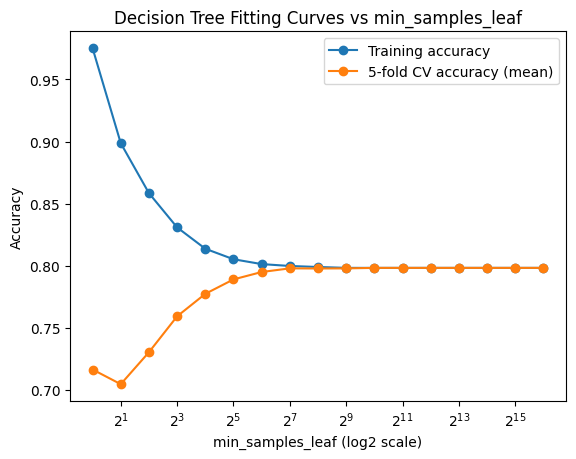

Best by mean CV accuracy: 1024 CV: 0.798119729531346 Train: 0.79811972926997
1-SE rule choice: 65536 threshold: 0.7981132703705884


In [32]:
# Put your answer here
import matplotlib.pyplot as plt
%matplotlib inline

# Target and features
# Ensure target is numeric: 1 = no-show, 0 = showed up
if not pd.api.types.is_numeric_dtype(df["No-show"]):
    df["No-show"] = (df["No-show"].astype(str).str.strip().str.lower() == "yes").astype(int)

y = df["No-show"]
X = df.drop(columns=["No-show"])

leaf_sizes = (2 ** np.arange(0, 17)).tolist()  # 1..65536 doubling

rows = []
for leaf in leaf_sizes:
    clf = DecisionTreeClassifier(random_state=0, min_samples_leaf=leaf)
    clf.fit(X, y)

    train_acc = clf.score(X, y)
    cv_scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
    rows.append({
        "min_samples_leaf": leaf,
        "train_accuracy": train_acc,
        "cv_accuracy_mean": cv_scores.mean(),
        "cv_accuracy_std": cv_scores.std()
    })

results = pd.DataFrame(rows)
print(results)

# Plot fitting curves (log2 x-axis)
plt.figure()
plt.plot(results["min_samples_leaf"], results["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(results["min_samples_leaf"], results["cv_accuracy_mean"], marker="o", label="5-fold CV accuracy (mean)")
plt.xscale("log", base=2)
plt.xlabel("min_samples_leaf (log2 scale)")
plt.ylabel("Accuracy")
plt.title("Decision Tree Fitting Curves vs min_samples_leaf")
plt.legend()
plt.show()

# Pick best by highest mean CV accuracy
best_idx = results["cv_accuracy_mean"].idxmax()
best_leaf = int(results.loc[best_idx, "min_samples_leaf"])
best_cv = float(results.loc[best_idx, "cv_accuracy_mean"])
best_train = float(results.loc[best_idx, "train_accuracy"])
print("Best by mean CV accuracy:", best_leaf, "CV:", best_cv, "Train:", best_train)

# Optional: 1-standard-error rule (prefer simpler tree if performance is similar)
k = 5
best_se = float(results.loc[best_idx, "cv_accuracy_std"]) / np.sqrt(k)
threshold = best_cv - best_se

candidates = results[results["cv_accuracy_mean"] >= threshold]
one_se_leaf = int(candidates["min_samples_leaf"].max())  # largest leaf (simplest model) within 1 SE of best
print("1-SE rule choice:", one_se_leaf, "threshold:", threshold)


**17. (Optional) Do you think the accuracy of the model you built is good or not? Why? What other additional information would be useful to evaluate whether the model is any good? How would you use that information to evaluate the model?**

In [ ]:
# Put your (optional) answer here (use 'markdown' rather than 'code').

18. **(Optional) Looking forward to the next class: Do the exact same analysis, but instead of accuracy use the area under the ROC curve (which we will talk about).  [Hint: sklearn has a method "roc_auc_score" and you have to use predict_proba instead of just predict--which we did in a prior notebook when visualizing the probabilities.]  If this were the right accuracy metric for the task, would you come to a different conclusion than you did above?**

In [ ]:
# Put your answer here